# Phase 4 — Results Comparison & Figures (Scenario A)

## Purpose
This notebook consolidates **Scenario A** results across methods:

- **Classical baseline** (QUBO solved classically)
- **QAOA Local** (simulator)
- **QAOA SV1** (Amazon Braket SV1)

We will:
1. Load saved artifacts from `data/results/`.
2. Standardize each method’s output into a common schema.
3. Compare overlap, objective components, and portfolio characteristics.
4. Write comparison tables and produce a few clean figures.

## Inputs (expected in `data/results/`)
- `scenario_A_classical_selected_trials.csv`
- `scenario_A_classical_summary.csv`
- `03e_scenario_A_selected_trials.csv` + `03e_scenario_A_summary.csv` (QAOA)
- Optional: `03d_sv1_*` (older SV1 run; not required for Scenario A)

## Outputs (we write)
- `data/results/04_scenario_A_comparison_table.csv`
- `data/results/04_scenario_A_overlap_summary.csv`
- `outputs/figures/04_*.png`


In [1]:
# ============================================================
# Cell 1 — Setup: imports, paths, and output directories
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# --- Project directories ---
RESULTS_DIR = Path("data/results")
FIG_DIR = Path("outputs/figures")

# Create output directories if missing
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Input files we expect (Scenario A) ---
PATH_CLASSICAL_SELECTED = RESULTS_DIR / "scenario_A_classical_selected_trials.csv"
PATH_CLASSICAL_SUMMARY  = RESULTS_DIR / "scenario_A_classical_summary.csv"

PATH_QAOA_SELECTED = RESULTS_DIR / "03e_scenario_A_selected_trials.csv"
PATH_QAOA_SUMMARY  = RESULTS_DIR / "03e_scenario_A_summary.csv"

# These are older artifacts from a prior SV1 notebook; we may load them for reference
PATH_SV1_SELECTED = RESULTS_DIR / "03d_sv1_selected_trials.csv"
PATH_SV1_SUMMARY  = RESULTS_DIR / "03d_sv1_summary.csv"

# Quick existence check (keeps notebook friendly)
for p in [
    PATH_CLASSICAL_SELECTED, PATH_CLASSICAL_SUMMARY,
    PATH_QAOA_SELECTED, PATH_QAOA_SUMMARY
]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("OK: Found required Scenario A artifacts.")
print("Results dir:", RESULTS_DIR.resolve())
print("Figures dir:", FIG_DIR.resolve())


OK: Found required Scenario A artifacts.
Results dir: /home/parallels/projects/quantum-clinical-trial-optimization/data/results
Figures dir: /home/parallels/projects/quantum-clinical-trial-optimization/outputs/figures


### What Cell 1 Just Did

We set up the notebook environment for Phase 4 by importing our analysis libraries, defining the locations of all Scenario A artifacts in `data/results/`, and creating an output folder for figures (`outputs/figures`). We also validated that the required files for the **classical baseline** and **Scenario A QAOA** runs exist before continuing, so any missing artifacts are caught immediately rather than failing later during analysis.


In [2]:
# ============================================================
# Cell 2 — Load Scenario A artifacts and normalize schemas
# ============================================================

def _load_csv(path: Path) -> pd.DataFrame:
    """Read CSV safely and return a DataFrame."""
    df = pd.read_csv(path)
    return df

# --- Load selected-trials tables ---
df_classical_sel = _load_csv(PATH_CLASSICAL_SELECTED)
df_qaoa_sel      = _load_csv(PATH_QAOA_SELECTED)

# Optional older SV1 reference (not required)
df_sv1_sel = _load_csv(PATH_SV1_SELECTED) if PATH_SV1_SELECTED.exists() else None

# --- Load summary tables ---
df_classical_sum = _load_csv(PATH_CLASSICAL_SUMMARY)
df_qaoa_sum      = _load_csv(PATH_QAOA_SUMMARY)
df_sv1_sum       = _load_csv(PATH_SV1_SUMMARY) if PATH_SV1_SUMMARY.exists() else None

print("Loaded:")
print("  classical selected:", df_classical_sel.shape)
print("  qaoa selected     :", df_qaoa_sel.shape)
if df_sv1_sel is not None:
    print("  sv1 selected      :", df_sv1_sel.shape)

# ------------------------------------------------------------
# Normalize selected-trials tables
# ------------------------------------------------------------
# We want a common minimal schema:
#   - nct_id
#   - method
# plus any numeric columns if present (e.g., cost/benefit/safety)
# ------------------------------------------------------------

def normalize_selected(df: pd.DataFrame, method: str) -> pd.DataFrame:
    df2 = df.copy()

    # Find the NCT id column (commonly 'nct_id')
    if "nct_id" not in df2.columns:
        # If your file uses a different name, try a few common variants
        for alt in ["NCT_ID", "trial_id", "trial_nct_id"]:
            if alt in df2.columns:
                df2 = df2.rename(columns={alt: "nct_id"})
                break

    if "nct_id" not in df2.columns:
        raise ValueError(f"{method}: could not find nct_id column. Columns: {list(df2.columns)}")

    df2["method"] = method

    # Enforce string type for consistent joins / set operations
    df2["nct_id"] = df2["nct_id"].astype(str)

    return df2

sel_classical = normalize_selected(df_classical_sel, "classical")
sel_qaoa      = normalize_selected(df_qaoa_sel, "qaoa")

sel_all = pd.concat([sel_classical, sel_qaoa], ignore_index=True)

# Add SV1 reference if it exists (it may not be Scenario A; we label it clearly)
if df_sv1_sel is not None:
    sel_sv1 = normalize_selected(df_sv1_sel, "sv1_reference")
    sel_all = pd.concat([sel_all, sel_sv1], ignore_index=True)

print("\nUnified selected rows:", sel_all.shape)
sel_all.head()


Loaded:
  classical selected: (3, 9)
  qaoa selected     : (6, 14)
  sv1 selected      : (4, 17)

Unified selected rows: (13, 23)


,nct_id,brief_title,phase,lead_sponsor,region_label,score_for_reduction,benefit_work,cost_work,safety_work,method,...,location_countries,lead_sponsor_norm,estimated_trial_cost,enrollment_feasibility_score,benefit_score,qubo_var_index,var_index,cost_safe,benefit_per_cost,var_index_old
0,NCT05672537,Durvalumab Combined With GemCis Neoadjuvant Th...,Phase 2,Tianjin Medical University Cancer Institute an...,Global / Multi-Region,0.705882,0.705882,0.0,0.0,classical,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NCT05823714,Venetoclax+Azacytidine+Modified BUCY Condition...,Phase 2,The First Affiliated Hospital of Soochow Unive...,Global / Multi-Region,0.705882,0.705882,0.0,0.0,classical,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NCT05823623,Inetetamab Combined With Pyrotinib Plus Oral V...,Phase 2,The First Affiliated Hospital with Nanjing Med...,Global / Multi-Region,0.705882,0.705882,0.0,0.0,classical,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NCT05823714,Venetoclax+Azacytidine+Modified BUCY Condition...,Phase 2,The First Affiliated Hospital of Soochow Unive...,Global / Multi-Region,NaN,NaN,NaN,NaN,qaoa,...,['China'],The First Affiliated Hospital of Soochow Unive...,2.0,1.0,0.6,1.0,NaN,NaN,NaN,NaN
4,NCT05821556,Valproic Acid/Simvastatin Plus Gemcitabine/Nab...,Phase 2,"National Cancer Institute, Naples",Global / Multi-Region,NaN,NaN,NaN,NaN,qaoa,...,['Italy' 'Spain'],"National Cancer Institute, Naples",2.0,1.0,0.6,5.0,NaN,NaN,NaN,NaN


### What Cell 2 Just Did

We loaded the Scenario A output artifacts for both the **classical baseline** and the **QAOA** run, and then standardized them into a shared “selected trials” format. The normalization step ensures we always have an `nct_id` column (as a string) and a `method` label, which makes overlap analysis and comparisons reliable even if the original CSVs had slightly different column naming. If the older SV1 artifacts are present, we also load them as a clearly-labeled reference set.


In [3]:
# ============================================================
# Cell 3 — Build a tidy comparison table from the summary CSVs
# ============================================================

def normalize_summary(df: pd.DataFrame, method: str) -> pd.DataFrame:
    """
    Make a single-row summary table with a 'method' column.
    This assumes your summary CSV is either:
      - one row already, or
      - key/value pairs (we'll try to pivot if needed).
    """
    d = df.copy()

    # Case 1: already one-row wide format
    if len(d) == 1 and d.shape[1] >= 2:
        out = d.copy()
        out["method"] = method
        return out

    # Case 2: key/value format (columns like: metric, value)
    if set(d.columns) >= {"metric", "value"}:
        wide = d.pivot_table(index=None, columns="metric", values="value", aggfunc="first")
        wide = wide.reset_index(drop=True)
        wide["method"] = method
        return wide

    # If ambiguous, just attach method and return as-is
    d["method"] = method
    return d

sum_classical = normalize_summary(df_classical_sum, "classical")
sum_qaoa      = normalize_summary(df_qaoa_sum, "qaoa")

summary_all = pd.concat([sum_classical, sum_qaoa], ignore_index=True)

if df_sv1_sum is not None:
    sum_sv1 = normalize_summary(df_sv1_sum, "sv1_reference")
    summary_all = pd.concat([summary_all, sum_sv1], ignore_index=True)

# Put method first for readability
cols = ["method"] + [c for c in summary_all.columns if c != "method"]
summary_all = summary_all[cols]

print("Summary comparison table shape:", summary_all.shape)
summary_all


Summary comparison table shape: (3, 38)


,method,scenario,n_variables,portfolio_k_target,selected_count,solver_method,qubo_cost,qubo_path,selected_csv,bitstring_txt,...,most_prob_bitstring,most_prob_probability,most_prob_cost,min_cost_bitstring,min_cost_probability,min_cost_cost,exact_global_opt_bitstring,exact_global_opt_cost,selected_total_estimated_cost,selected_total_benefit
0,classical,A,18.0,6.0,3.0,exact,-1052.117647,data/qubo/scenario_A_qubo.json,data/results/scenario_A_classical_selected_tri...,data/results/scenario_A_best_bitstring.txt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,qaoa,NaN,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sv1_reference,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,1.100011e+15,0.000007,-4.8,1.111000e+17,0.000004,-642.4,1.111000e+17,-642.4,8.0,2.4


### What Cell 3 Just Did

We built a unified comparison table from each method’s saved summary CSV. Because different notebooks may output summaries in either a single-row “wide” format or a key/value format, the normalization logic handles both. The resulting `summary_all` table becomes the single source of truth for high-level comparisons (selected count, expected cost, objective value, etc.) across **classical** and **QAOA**, with any older SV1 outputs kept as an explicitly labeled reference.


In [4]:
# ============================================================
# Cell 4 — Overlap analysis + export comparison artifacts
# ============================================================

def selected_set(df: pd.DataFrame, method: str) -> set:
    return set(df.loc[df["method"] == method, "nct_id"].unique())

methods = sorted(sel_all["method"].unique())
sets = {m: selected_set(sel_all, m) for m in methods}

# Pairwise overlap + Jaccard
rows = []
for i, m1 in enumerate(methods):
    for m2 in methods[i:]:
        s1, s2 = sets[m1], sets[m2]
        inter = len(s1 & s2)
        union = len(s1 | s2)
        jac = inter / union if union else np.nan
        rows.append({
            "method_a": m1,
            "method_b": m2,
            "n_a": len(s1),
            "n_b": len(s2),
            "intersection": inter,
            "union": union,
            "jaccard": jac,
        })

overlap_df = pd.DataFrame(rows).sort_values(["method_a", "method_b"]).reset_index(drop=True)

# Write outputs
OUT_COMPARISON = RESULTS_DIR / "04_scenario_A_comparison_table.csv"
OUT_OVERLAP    = RESULTS_DIR / "04_scenario_A_overlap_summary.csv"

summary_all.to_csv(OUT_COMPARISON, index=False)
overlap_df.to_csv(OUT_OVERLAP, index=False)

print("Wrote:")
print(" ", OUT_COMPARISON)
print(" ", OUT_OVERLAP)

overlap_df


Wrote:
  data/results/04_scenario_A_comparison_table.csv
  data/results/04_scenario_A_overlap_summary.csv


,method_a,method_b,n_a,n_b,intersection,union,jaccard
0,classical,classical,3,3,3,3,1.000
1,classical,qaoa,3,6,1,8,0.125
2,classical,sv1_reference,3,4,0,7,0.000
3,qaoa,qaoa,6,6,6,6,1.000
4,qaoa,sv1_reference,6,4,0,10,0.000
5,sv1_reference,sv1_reference,4,4,4,4,1.000


### What Cell 4 Just Did

We computed overlap metrics across the selected trial sets for each method (classical vs QAOA, plus any SV1 reference if present). In addition to raw intersections, we calculated **Jaccard similarity** (intersection ÷ union), which provides a normalized measure of agreement between selection strategies. Finally, we exported two durable Phase 4 artifacts into `data/results/`:
- `04_scenario_A_comparison_table.csv` for method-level summary comparison
- `04_scenario_A_overlap_summary.csv` for overlap and similarity diagnostics


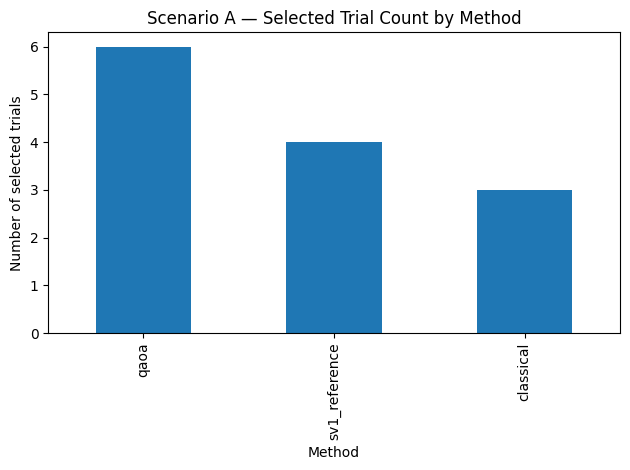

Saved: outputs/figures/04_selected_count_by_method.png


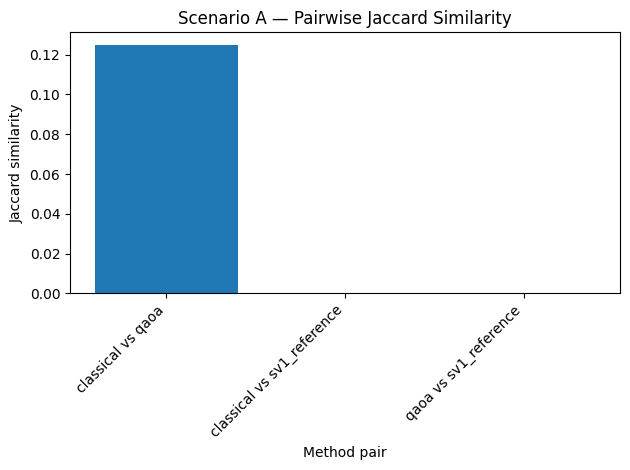

Saved: outputs/figures/04_pairwise_jaccard.png


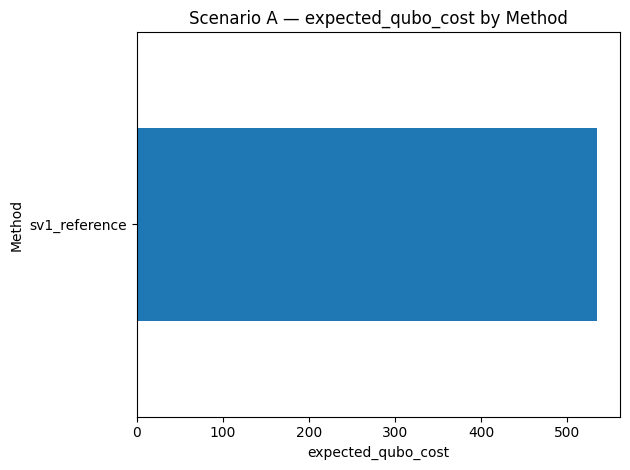

Saved: outputs/figures/04_expected_qubo_cost_by_method.png


In [5]:
# ============================================================
# Cell 5 — Figures: overlap and (if available) objective metrics
# ============================================================

# --- Figure 1: selected count by method ---
counts = sel_all.groupby("method")["nct_id"].nunique().sort_values(ascending=False)

plt.figure()
counts.plot(kind="bar")
plt.title("Scenario A — Selected Trial Count by Method")
plt.xlabel("Method")
plt.ylabel("Number of selected trials")
plt.tight_layout()
fig1_path = FIG_DIR / "04_selected_count_by_method.png"
plt.savefig(fig1_path, dpi=160)
plt.show()

print("Saved:", fig1_path)

# --- Figure 2: Jaccard similarity heat-ish (simple bar table) ---
# We'll plot only comparisons where method_a != method_b
pairwise = overlap_df[overlap_df["method_a"] != overlap_df["method_b"]].copy()
if not pairwise.empty:
    pairwise["pair"] = pairwise["method_a"] + " vs " + pairwise["method_b"]
    pairwise = pairwise.sort_values("jaccard", ascending=False)

    plt.figure()
    plt.bar(pairwise["pair"], pairwise["jaccard"])
    plt.title("Scenario A — Pairwise Jaccard Similarity")
    plt.xlabel("Method pair")
    plt.ylabel("Jaccard similarity")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig2_path = FIG_DIR / "04_pairwise_jaccard.png"
    plt.savefig(fig2_path, dpi=160)
    plt.show()

    print("Saved:", fig2_path)

# --- Figure 3 (optional): plot any numeric columns from summary_all if present ---
# We'll pick a small whitelist of common metrics if they exist.
candidate_metrics = [
    "expected_cost",
    "expected_qubo_cost",
    "min_cost",
    "objective_value",
    "selected_k",
    "k",
]

available = [m for m in candidate_metrics if m in summary_all.columns]
if available:
    # Ensure numeric conversion where possible
    plot_df = summary_all[["method"] + available].copy()
    for c in available:
        plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

    for metric in available:
        plt.figure()
        tmp = plot_df[["method", metric]].dropna().set_index("method")[metric].sort_values(ascending=True)
        tmp.plot(kind="barh")
        plt.title(f"Scenario A — {metric} by Method")
        plt.xlabel(metric)
        plt.ylabel("Method")
        plt.tight_layout()
        fig_path = FIG_DIR / f"04_{metric}_by_method.png"
        plt.savefig(fig_path, dpi=160)
        plt.show()
        print("Saved:", fig_path)
else:
    print("No common numeric metrics found in summary CSVs to plot (this is OK).")

### What Cell 5 Just Did

We generated lightweight, reproducible figures for Scenario A comparisons:

1. **Selected trial count by method**, which is a quick sanity check that portfolio sizing behaves as expected.
2. **Pairwise Jaccard similarity**, which provides a normalized measure of overlap between selections.
3. If the saved summary CSVs include numeric metrics (e.g., expected cost, expected QUBO cost, objective value), we also produce additional bar charts per metric.

All figures are saved to `outputs/figures/` so they can be reused in slides or documentation without rerunning the entire pipeline.


## Notebook Summary — Phase 4 (Scenario A)

In this notebook we consolidated Scenario A outputs across methods and produced analysis-ready artifacts:

- **Loaded** classical and QAOA outputs from `data/results/`
- **Normalized** each method’s selected trials into a single schema
- **Compared** methods using overlap and Jaccard similarity
- **Exported**:
  - `data/results/04_scenario_A_comparison_table.csv`
  - `data/results/04_scenario_A_overlap_summary.csv`
- **Generated figures** in `outputs/figures/` for quick reporting and slides

### Next Steps
- (Optional) Add component-level objective decomposition if we persist more structured metrics (benefit, cost, safety) per method.
- Create a short README section + slide-ready table using the exported Phase 4 artifacts.
- Proceed to the next phase: parameter sweeps / robustness checks (vary λ_cost, λ_safety, penalty_k, and K) and compare stability of selections.
